# **1. Load the dataset**

In [13]:
import pandas as pd

# Load the dataset
file_path = "training.1600000.processed.noemoticon.csv"
columns = ["target", "id", "date", "flag", "user", "text"]
df = pd.read_csv(file_path, encoding="latin-1", names=columns)

# Display the first few rows
df.head()


,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


# **2. Text Cleaning**

In [14]:
import re

# Keep only the necessary columns
df = df[["target", "text"]]

# Convert sentiment labels: 0 -> Negative, 4 -> Positive
df["target"] = df["target"].replace({0: "negative", 4: "positive"})

# Function to clean text
def clean_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)  # Remove URLs
    text = re.sub(r"\b(feel|feels|feeling)\b", "", text, flags=re.IGNORECASE)
    text = re.sub(r"\@\w+|\#", "", text)  # Remove mentions and hashtags
    text = re.sub(r"[^\w\s]", "", text)  # Remove punctuation
    
    return text

# Apply cleaning function
df["text"] = df["text"].apply(clean_text)

# Display cleaned data
df.head()

,target,text
0,negative,a thats a bummer you shoulda got david car...
1,negative,is upset that he cant update his facebook by t...
2,negative,i dived many times for the ball managed to sa...
3,negative,my whole body itchy and like its on fire
4,negative,no its not behaving at all im mad why am i he...


# **3. Convert Text into Numerical Representations**

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=47000)  # Limit vocabulary size

# Fit and transform the text data
X = vectorizer.fit_transform(df["text"])

# Convert sentiment labels to numerical values (0 for negative, 1 for positive)
y = df["target"].map({"negative": 0, "positive": 1})

# **4. Model Training**

**Logistic Regression**

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train Logistic Regression model
lr_model = LogisticRegression(max_iter=500)
lr_model.fit(X_train, y_train)

# Predict on test data
y_pred = lr_model.predict(X_test)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

# Get classification report
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

Model Accuracy: 0.80
              precision    recall  f1-score   support

    Negative       0.80      0.78      0.79    159494
    Positive       0.79      0.81      0.80    160506

    accuracy                           0.80    320000
   macro avg       0.80      0.80      0.80    320000
weighted avg       0.80      0.80      0.80    320000



**Naive Bayes**

In [17]:
from sklearn.naive_bayes import MultinomialNB

# Train a Naive Bayes classifier
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Predict on test set
y_pred_nb = nb_model.predict(X_test)

# Evaluate the model
accuracy_nb = accuracy_score(y_test, y_pred_nb)
report_nb = classification_report(y_test, y_pred_nb, target_names=["Negative", "Positive"])

print(f"Model Accuracy: {accuracy_nb:.2f}")
print("Classification Report:\n", report_nb)

Model Accuracy: 0.77
Classification Report:
               precision    recall  f1-score   support

    Negative       0.77      0.78      0.78    159494
    Positive       0.78      0.76      0.77    160506

    accuracy                           0.77    320000
   macro avg       0.77      0.77      0.77    320000
weighted avg       0.77      0.77      0.77    320000



**XGBoost**

In [18]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

# Convert data to DMatrix (optional but efficient for large data)
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Set parameters
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'max_depth': 6,
    'eta': 0.1,
    'seed': 42,
}

# Train the model
xgb_model = xgb.train(params, dtrain, num_boost_round=100)

# Predict and evaluate
y_pred_xgb = xgb_model.predict(dtest)
y_pred_xgb_labels = [1 if y > 0.5 else 0 for y in y_pred_xgb]

accuracy_xgb = accuracy_score(y_test, y_pred_xgb_labels)
report_xgb = classification_report(y_test, y_pred_xgb_labels, target_names=["Negative", "Positive"])

print(f"Model Accuracy: {accuracy_xgb:.2f}")
print("Classification Report:\n", report_xgb)

Model Accuracy: 0.73
Classification Report:
               precision    recall  f1-score   support

    Negative       0.76      0.65      0.70    159494
    Positive       0.70      0.80      0.75    160506

    accuracy                           0.73    320000
   macro avg       0.73      0.73      0.72    320000
weighted avg       0.73      0.73      0.72    320000



**SVM**

In [24]:
import sklearn
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

# Train the SVM model
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_svm = svm_model.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
report_svm = classification_report(y_test, y_pred_svm, target_names=["Negative", "Positive"])

print(f"Model Accuracy: {accuracy_svm:.2f}")
print("Classification Report:\n", report_svm)

Model Accuracy: 0.79
Classification Report:
               precision    recall  f1-score   support

    Negative       0.80      0.78      0.79    159494
    Positive       0.79      0.81      0.80    160506

    accuracy                           0.79    320000
   macro avg       0.79      0.79      0.79    320000
weighted avg       0.79      0.79      0.79    320000



**Random Forest**

In [20]:
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create a balanced subset (10,000 positive and 10,000 negative)
pos_indices = np.where(y == 1)[0]
neg_indices = np.where(y == 0)[0]

np.random.seed(42)
pos_sample = np.random.choice(pos_indices, 10000, replace=False)
neg_sample = np.random.choice(neg_indices, 10000, replace=False)

subset_indices = np.concatenate((pos_sample, neg_sample))
X_subset = X[subset_indices]
y_subset = y[subset_indices]

# Shuffle the subset before training
X_subset, y_subset = sklearn.utils.shuffle(X_subset, y_subset, random_state=42)

# Train/test split (reuse X_subset and y_subset)
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_subset, y_subset, test_size=0.2, random_state=42)

# Train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_model.fit(X_train_rf, y_train_rf)

# Predict and evaluate
y_pred_rf = rf_model.predict(X_test_rf)
accuracy_rf = accuracy_score(y_test_rf, y_pred_rf)
report_rf = classification_report(y_test_rf, y_pred_rf, target_names=["Negative", "Positive"])

print(f"Model Accuracy: {accuracy_rf:.2f}")
print("Classification Report:\n", report_rf)

Model Accuracy: 0.75
Classification Report:
               precision    recall  f1-score   support

    Negative       0.74      0.75      0.74      1945
    Positive       0.76      0.75      0.76      2055

    accuracy                           0.75      4000
   macro avg       0.75      0.75      0.75      4000
weighted avg       0.75      0.75      0.75      4000



# **5. Result Visualization**

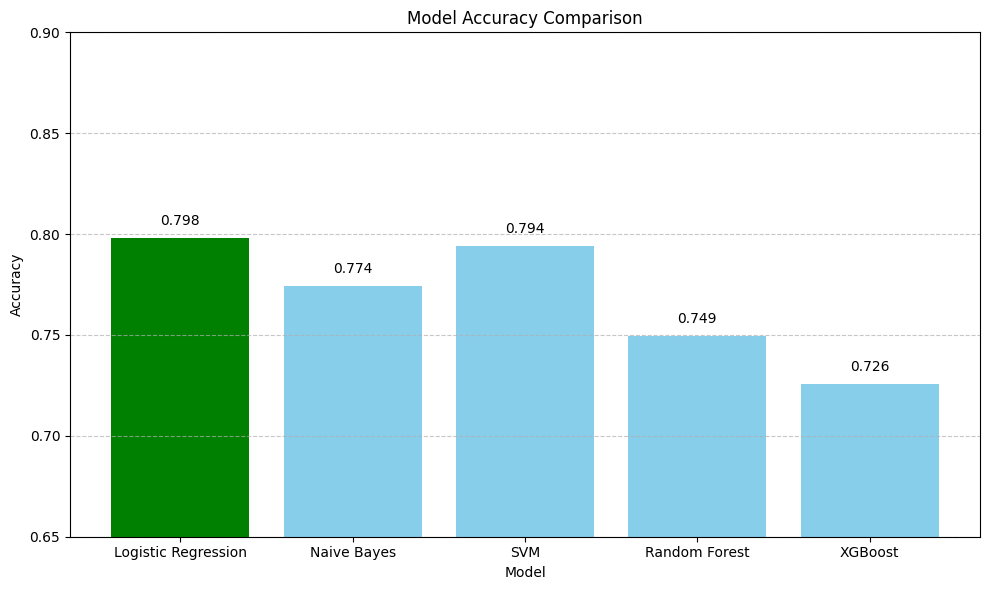

In [21]:
import matplotlib.pyplot as plt

# If you haven't already, assign Logistic Regression accuracy to a variable:
accuracy_lr = accuracy_score(y_test, y_pred)

# Gather model names and their corresponding accuracy variables
model_names = ['Logistic Regression', 'Naive Bayes', 'SVM', 'Random Forest', 'XGBoost']
accuracies = [accuracy_lr, accuracy_nb, accuracy_svm, accuracy_rf, accuracy_xgb]

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, accuracies, color=['green' if acc == max(accuracies) else 'skyblue' for acc in accuracies])
plt.ylim(0.65, 0.9)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Label bars with accuracy values
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, acc + 0.005, f'{acc:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# **6. Define chabot responses**

In [22]:
import random

# Define responses for each sentiment
positive_responses = [
    "I'm glad you're feeling good! 😊",
    "That's great to hear! Keep up the positivity! 🌟",
    "Sounds like you're having a great day!"
]

negative_responses = [
    "I'm sorry you're feeling this way. Remember, you're not alone. ❤️",
    "It's okay to feel down sometimes. Want to talk about it?",
    "I'm here to listen. What's on your mind?"
]

# Function to generate response based on sentiment
def get_chatbot_response(text):
    # Transform text using the TF-IDF vectorizer
    text_tfidf = vectorizer.transform([text])

    # Predict sentiment (0 = Negative, 1 = Positive)
    sentiment = lr_model.predict(text_tfidf)[0]

    # Select a random response from the appropriate list
    if sentiment == 1:
        return random.choice(positive_responses)
    else:
        return random.choice(negative_responses)

# Example usage
print(get_chatbot_response("I feel so happy today!"))
print(get_chatbot_response("I'm feeling really down..."))


I'm glad you're feeling good! 😊
I'm here to listen. What's on your mind?


# **7. Save the Model and the Vectorizer**

In [40]:
import pickle

# Save the trained SVM model
with open("sentiment_model.pkl", "wb") as model_file:
    pickle.dump(lr_model, model_file)

# Save the TF-IDF vectorizer
with open("tfidf_vectorizer.pkl", "wb") as vectorizer_file:
    pickle.dump(vectorizer, vectorizer_file)

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!
